**Plotagem do histograma**

In [10]:
# Bibliotecas
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt

In [11]:
# Exibe uma janela para a seleção de um arquivo
from google.colab import files
arquivo = files.upload()
img_name = next(iter(arquivo))

# Leitura da imagem pelo cv2, convertido para tons de cinza
image = cv2.imread(img_name, cv2.IMREAD_GRAYSCALE)

Saving Contrast.png to Contrast (2).png


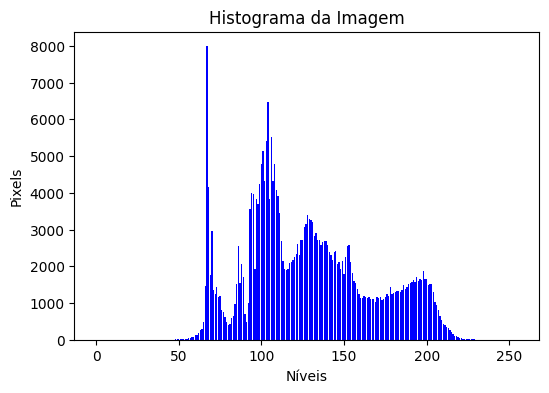

In [31]:
# Vetor com 256 níveis (profundidade de 8 bits)
dist = np.zeros(256, dtype=int)
indexes = list(range(len(dist)))

for i in range(image.shape[0]):
  for j in range(image.shape[1]):

    value = image[i,j]
    dist[value] += 1

# Plotagem do Histograma:
plt.figure(figsize=(6,4))
plt.bar(indexes,dist, color='blue')
plt.title("Histograma da Imagem")
plt.xlabel("Níveis")
plt.ylabel("Pixels")
plt.show()

**Equalização da imagem**

In [42]:
# Vetor com os níveis --> indexes
# Vetor com as quantidades --> dist

# Vetor para as probabilidades:
prob = np.zeros(256, dtype=float)
for i in range(len(prob)):
  prob[i] = dist[i] / (image.shape[0] * image.shape[1])

# Vetor para a CDF
cdf = np.zeros(256, dtype=float)
cdf[0] = prob[0]
for i in range(1, len(cdf)):
  cdf[i] = cdf[i-1] + prob[i]

# Calculo de sk (novos níveis):
sk = np.zeros(256, dtype=int)
for i in range(len(sk)):
  sk[i] = round(255 * cdf[i])

print("Níveis originais:")
print(indexes)
# Exibe uma lista 'limpa', apenas com os valores inteiros
print("Níveis transformados:")
print([int(x) for x in sk])

Níveis originais:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 2

**Novo histograma**

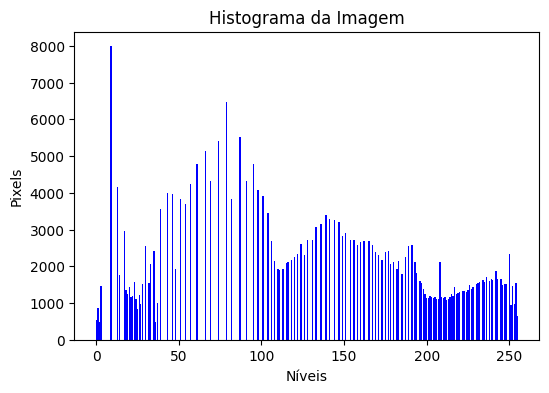

In [66]:
# Vetor com novas distribuições
new_dist = np.zeros(256, dtype=int)

for i in range(256):
  for j in range(256):
    if sk[i] == j:
      new_dist[j] += dist[i]

# Plotagem do novo histograma:
plt.figure(figsize=(6,4))
plt.bar(indexes, new_dist, color='blue')
plt.title("Histograma da Imagem")
plt.xlabel("Níveis")
plt.ylabel("Pixels")
plt.show()



In [67]:
print("Níveis originais:")
print(indexes)
print("Níveis transformados:")
print([int(x) for x in sk])
print("Distribuição original:")
print([int(x) for x in dist])
print("Distribuição equalizada:")
print([int(x) for x in new_dist])

Níveis originais:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 2

**Imagem Equalizada**

Text(0.5, 1.0, 'Imagem Equalizada')

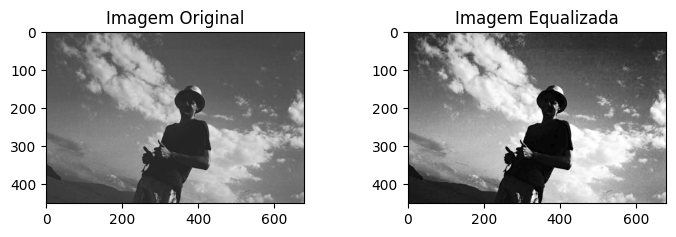

In [69]:
# Cria uma imagem nova com o mesmo tamanho da original
new_image = np.zeros_like(image)

# Percorre todos os pixels
for i in range(image.shape[0]):
    for j in range(image.shape[1]):

        # Intensidade original
        value = image[i, j]
        # Substitui pela nova intensidade
        new_image[i, j] = sk[value]

plt.figure(figsize=(8,8))
plt.subplots_adjust(wspace=0.4)

# plt.subplot(linhas, colunas, posição)
plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title("Imagem Original")

plt.subplot(1,2,2)
plt.imshow(new_image, cmap='gray')
plt.title("Imagem Equalizada")